* Predictive Maintenance

In [1]:
from all_imports import *
from variables import *
from pipeline import *
from functions import *

NameError: name 'st' is not defined

In [ ]:
comp_engine01_df = create_rul_col(comp_engine01_df)
comp_engine02_df = create_rul_col(comp_engine02_df)
comp_engine03_df = create_rul_col(comp_engine03_df)
comp_engine04_df = create_rul_col(comp_engine04_df)

In [ ]:
comp_engine03_df[comp_engine03_df['cycle'] == comp_engine03_df['cycle'].max()]

,engine,cycle,sensor1,sensor2,sensor3,sensor4,sensor5,sensor6,sensor7,sensor8,...,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21,rul
14375,55,525,518.67,643.67,1607.0,1424.15,14.62,21.57,569.73,2388.56,...,2388.6,8192.24,8.211,0.03,397,2388,100.0,39.56,23.8216,0


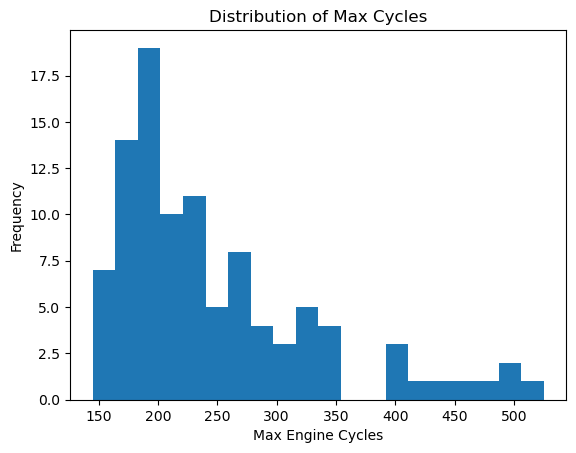

In [ ]:
comp01_list = []
comp02_list = []
comp03_list = []
comp04_list = []
for idx in range(1, 101):
    comp01_list.append(comp_engine01_df.loc[comp_engine01_df['engine'] == idx,'cycle'].max())
    comp02_list.append(comp_engine02_df.loc[comp_engine02_df['engine'] == idx,'cycle'].max())
    comp03_list.append(comp_engine03_df.loc[comp_engine03_df['engine'] == idx,'cycle'].max())
    comp04_list.append(comp_engine04_df.loc[comp_engine04_df['engine'] == idx,'cycle'].max())
plt.hist(comp03_list, bins=20)
plt.title('Distribution of Max Cycles')
plt.ylabel('Frequency')
plt.xlabel('Max Engine Cycles')
plt.show()

In [ ]:

# for i in range(1,10):
#     test_setting = f"setting3"
#     test_sensor = f"sensor{i}"
#     engine_series = comp_engine03_df.loc[comp_engine03_df['engine'] == 69,test_sensor]
#     cycle_series = comp_engine03_df.loc[comp_engine03_df['engine'] == 69,'cycle']
#     engine_series_2 = comp_engine01_df.loc[comp_engine01_df['engine'] == 39,test_sensor]
#     cycle_series_2 = comp_engine01_df.loc[comp_engine01_df['engine'] == 39,'cycle']
#     plt.scatter(cycle_series, engine_series, label="comp_engine03_df")
#     plt.scatter(cycle_series_2, engine_series_2, label="comp_engine01_df")
#     plt.title(f"Engine {1}")
#     plt.xlabel("Cycles")
#     plt.ylabel(f"{sensor_names[test_sensor]}")
#     plt.legend()
#     plt.show()
# sns.pairplot(comp_engine01_df[comp_engine01_df['engine'] == 1])

In [ ]:
# Regression Model
# X = comp_engine01_df[comp_engine01_df['engine'] == te].drop(columns=["engine", 'cycle'])
# y = comp_engine01_df[comp_engine01_df['engine'] == te]['cycle']
# te = 3
# me = 5
# X = comp_engine03_df.drop(columns=not_unique_col(comp_engine03_df)+["engine", 'rul'])
# y = comp_engine03_df['rul']
# X_train, X_test, y_train, y_test = train_test_split(
#     X,
#     y,
#     test_size=0.2,
#     random_state=42
# )
X_test_df = test_engine03_df.groupby('engine').last().drop(columns=not_unique_col(test_engine03_df)+['cycle'])
y_test_df = rul_engine03_df['rul']
X_train_df = comp_engine03_df.drop(columns=not_unique_col(comp_engine03_df)+["engine", 'rul']+['cycle'])
y_train_df = comp_engine03_df['rul']


rfr.fit(X_train_df, y_train_df)
print(f"Random Forest Regressor: {rfr.score(X_test_df, y_test_df)}")
# linreg.fit(X_train_df, y_train_df)
# print(f"Linear Regression: {linreg.score(X_test_df, y_test_df)}")
# dtr.fit(X_train_df, y_train_df)
# print(f"Descision Tree Regressor: {dtr.score(X_test, y_test)}")
xgbr.fit(X_train_df, y_train_df)
print(f"XGB Regressor: {xgbr.score(X_test_df, y_test_df)}")
# ridge_reg.fit(X_train, y_train)
# print(f"Ridge Regressor: {ridge_reg.score(X_test, y_test)}")
# lasso_reg.fit(X_train, y_train)
# print(f"Lasso Regressor: {lasso_reg.score(X_test, y_test)}")

Random Forest Regressor: -0.17467675374895464
XGB Regressor: -0.4400298595428467


In [ ]:
# Clip the Data
# X_test_df = test_engine03_df.groupby('engine').last().drop(columns=not_unique_col(test_engine03_df)+['cycle'])
# y_test_df = rul_engine03_df['rul']
# X_train_df = comp_engine03_df.drop(columns=not_unique_col(comp_engine03_df)+["engine", 'rul']+['cycle'])
y_train_clipped_df = y_train_df.clip(upper=120)# 112 or 120
rfr.fit(X_train_df, y_train_clipped_df)
# print(f"Random Forest Regressor: {rfr.score(X_test_df, y_test_df)}")
# xgbr.fit(X_train_df, y_train_df)
# print(f"XGB Regressor: {xgbr.score(X_test_df, y_test_df)}")

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['sensor2', 'sensor3',
                                                   'sensor4', 'sensor6',
                                                   'sensor7', 'sensor8',
                                                   'sensor9', 'sensor11',
                                                   'sensor12', 'sensor13',
                                                   'sensor14', 'sensor15',
                                                   'sensor17', 'sensor20',
                                                   'sensor21']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [])])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [ ]:
X_train_df.columns

Index(['sensor2', 'sensor3', 'sensor4', 'sensor6', 'sensor7', 'sensor8',
       'sensor9', 'sensor10', 'sensor11', 'sensor12', 'sensor13', 'sensor14',
       'sensor15', 'sensor17', 'sensor20', 'sensor21'],
      dtype='object')

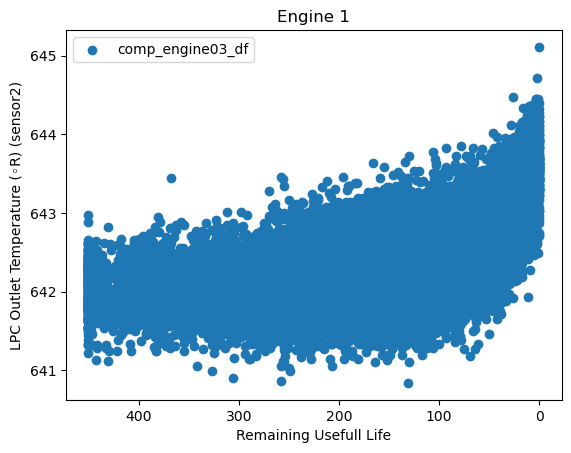

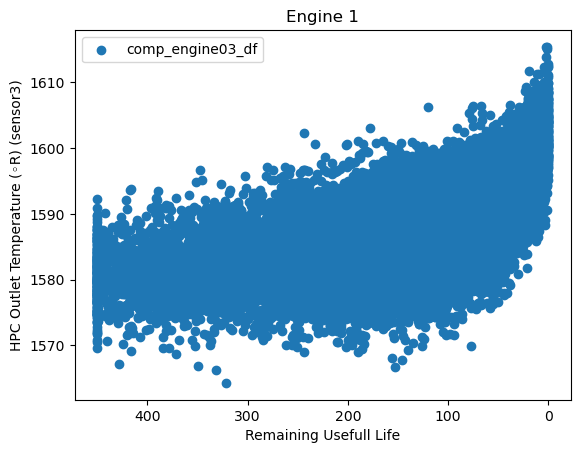

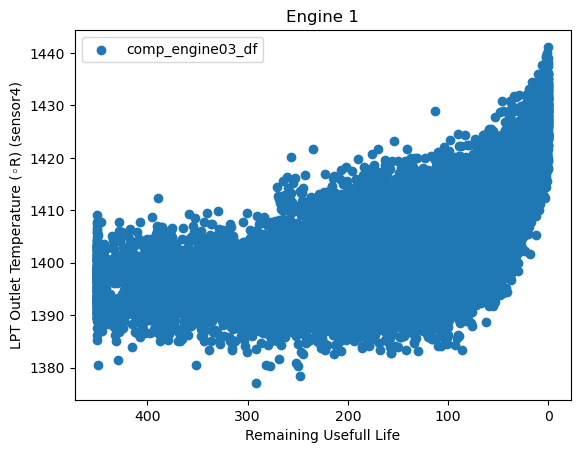

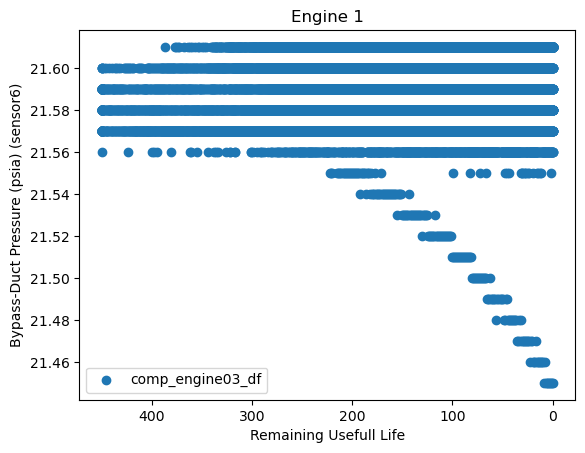

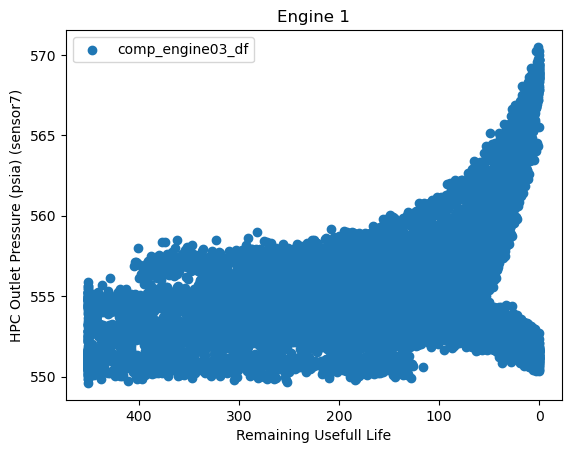

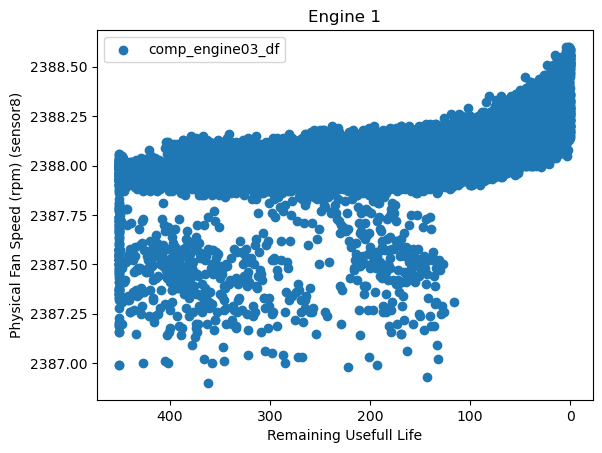

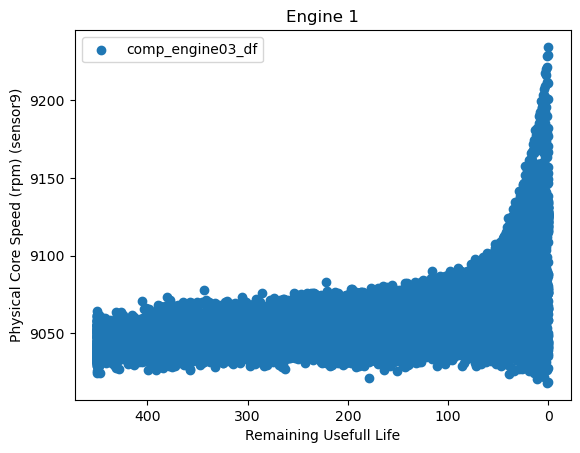

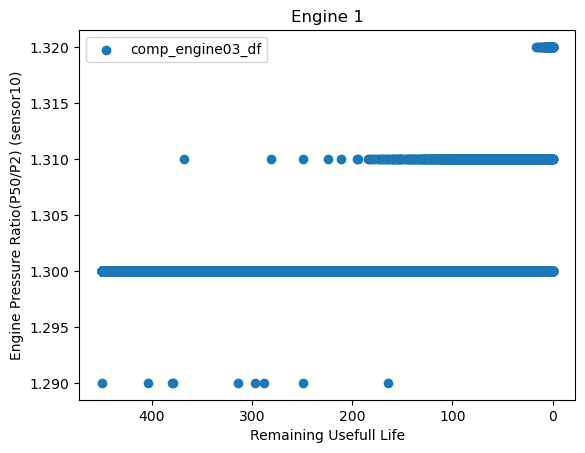

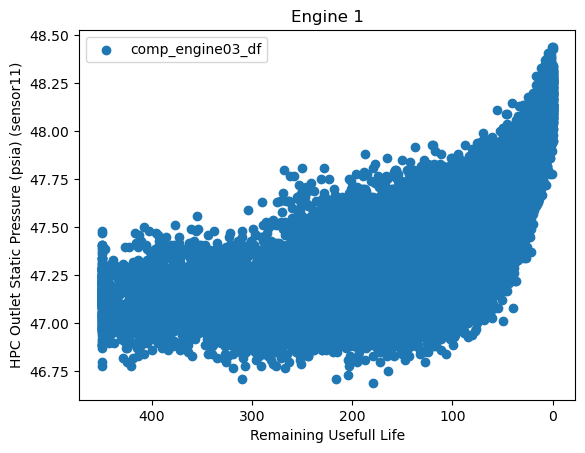

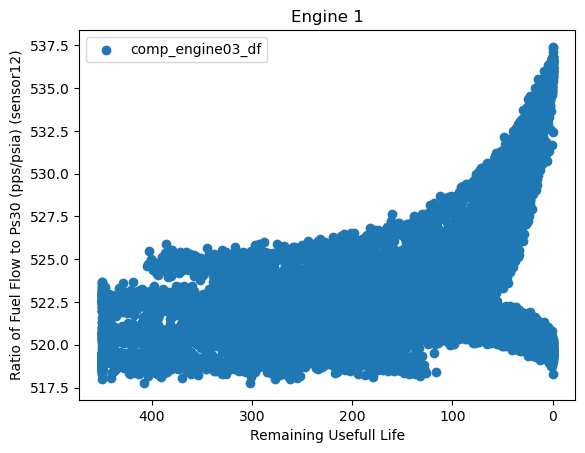

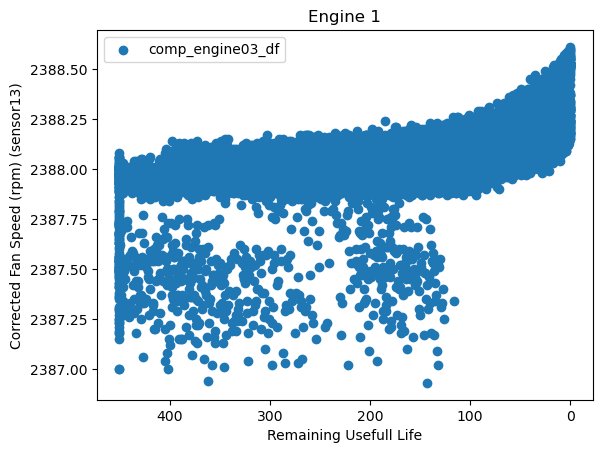

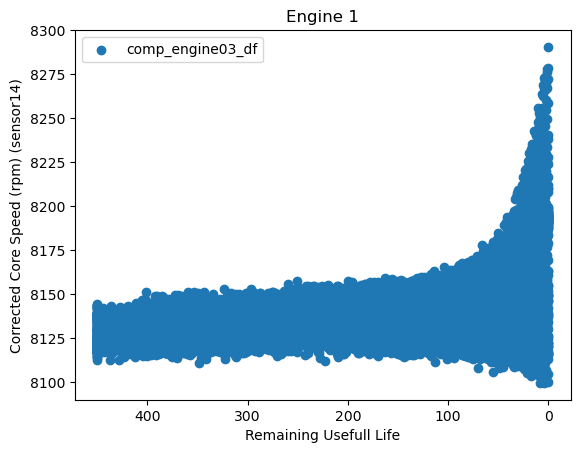

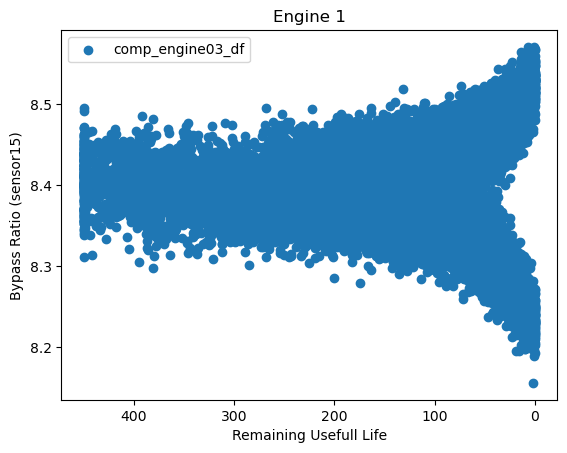

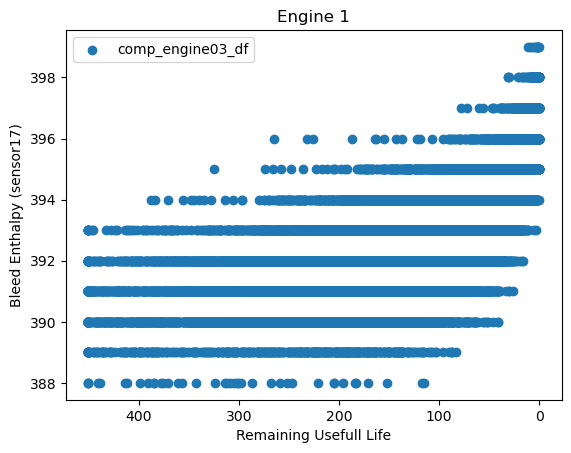

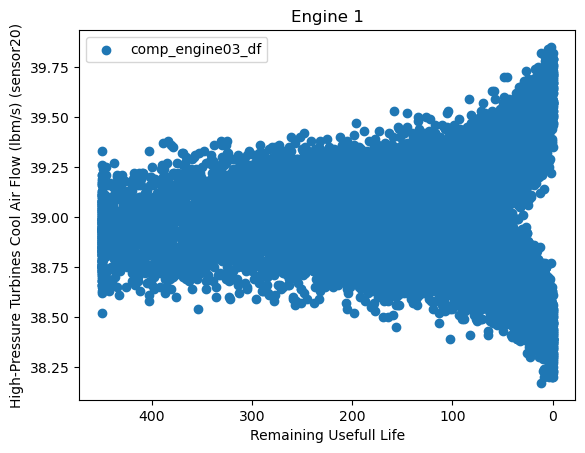

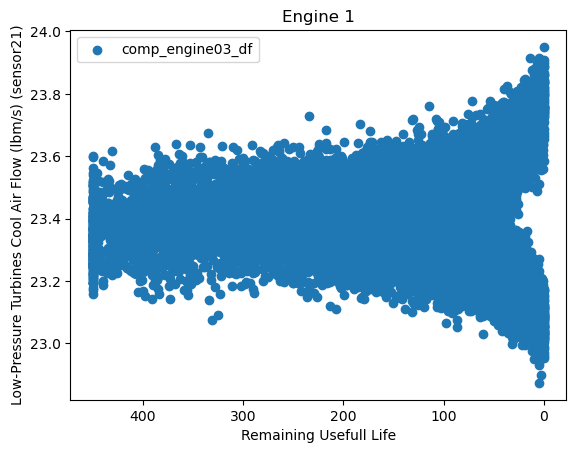

In [ ]:
for col in X_train_df.columns:
    engine_series_2 = X_train_df[col]
    cycle_series_2 = y_train_clipped_df
    plt.scatter(cycle_series_2, engine_series_2, label="comp_engine03_df")
    plt.title(f"Engine {1}")
    plt.xlabel("Remaining Usefull Life")
    plt.ylabel(f"{sensor_names[col]} ({col})")
    plt.gca().invert_xaxis()
    plt.legend()
    plt.show()

In [ ]:
# # mse for two potential models
# y_pred = rfr.predict(X_test_df)
# mse = mean_squared_error(y_test_df, y_pred)
# print("RFR RMSE:", np.sqrt(mse))
# y_pred = xgbr.predict(X_test_df)
# mse = mean_squared_error(y_test_df, y_pred)
# print("XGBR RMSE:", np.sqrt(mse))

In [ ]:
rfr_score_list = []
# linreg_score_list = []
# dtr_score_list = []
# xgbr_score_list = []
# ridge_score_list = []
# lasso_score_list = []
for i in range(1, 101):
    X = comp_engine03_df[comp_engine03_df['engine'] == i].drop(columns=not_unique_col(comp_engine03_df)+["engine", 'rul'])
    y = comp_engine03_df[comp_engine03_df['engine'] == i]['rul']
    rfr_score_list.append(rfr.score(X, y))
    # xgbr_score_list.append(xgbr.score(X,y))
    # for num in range(len(y)):
    #     y_pred = rfr.predict(X.iloc[[num]])
print(f"Average score for Random Forest Regressor: {np.mean(rfr_score_list)}")
# print(f"Average score for XGB Regressor: {np.mean(xgbr_score_list)}")

Average score for Random Forest Regressor: 0.918835416614207


Random Forest Regressor: 0.738467740034183

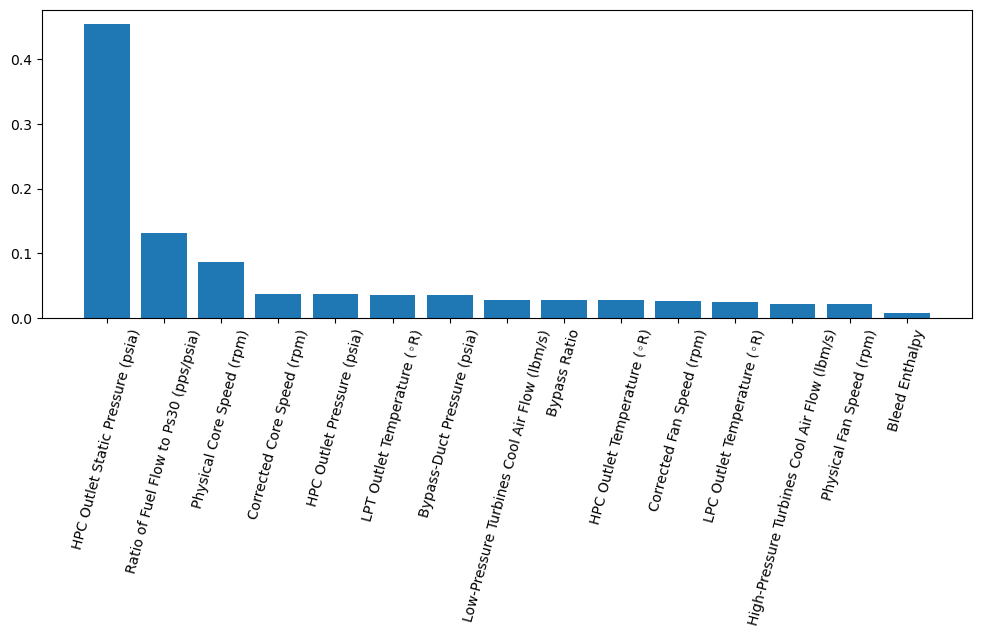

In [ ]:
rfr_model = rfr.named_steps["regressor"]
num_fet_name_list = [sensor_names[fet] for fet in numeric_features]

importances = pd.DataFrame(rfr_model.feature_importances_, columns=["Feature Importance"], index=num_fet_name_list).sort_values(by="Feature Importance", ascending=False)
fig, ax = plt.subplots(figsize=(12,4))
plt.bar(importances.index, importances["Feature Importance"])
plt.xticks(rotation=75);

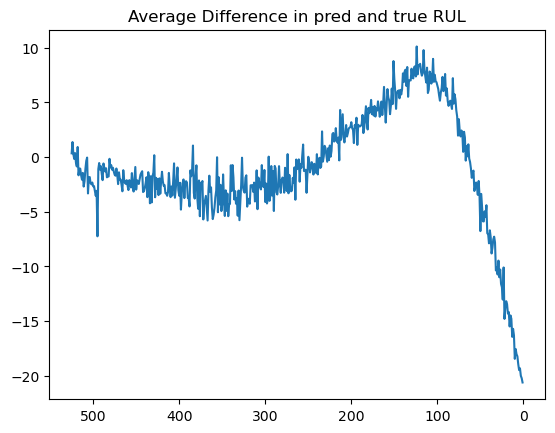

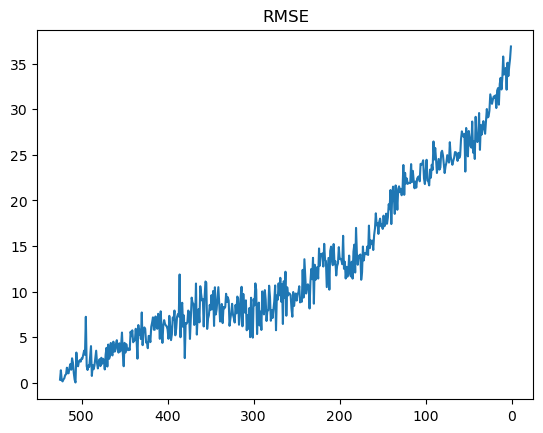

In [ ]:
# score based off only sensor data from the first cycle
avg_dif_pred = []
rmse_list = []
for i in range(1, 526):
    X = comp_engine03_df[(comp_engine03_df['cycle'] == i)].drop(columns=not_unique_col(comp_engine03_df)+["engine", 'rul', 'cycle'])
    y = comp_engine03_df[(comp_engine03_df['cycle'] == i)]['rul']
    y_pred = rfr.predict(X)
    mse = mean_squared_error(y, y_pred)
    rmse_list.append(np.sqrt(mse))
    # print("RMSE:", np.sqrt(mse))
    # print("Score:", rfr.score(X, y))
    # Average prediction was high or low compared to actual
    # print("The Average Difference between pred and true:", np.mean(y_pred - y))
    avg_dif_pred.append(np.mean(y_pred - y))
plt.plot(range(1, 526), avg_dif_pred)
plt.title('Average Difference in pred and true RUL')
plt.gca().invert_xaxis()
plt.show()
plt.plot(range(1, 526), rmse_list)
plt.title('RMSE')
plt.gca().invert_xaxis()
plt.show()

In [ ]:
# score based off only sensor data from the last cycle
# X_test_df = test_engine03_df.groupby('engine').last().drop(columns=not_unique_col(test_engine03_df)+["cycle"])
# y_test_df = rul_engine03_df['rul']
y_pred = rfr.predict(X_test_df)
mse = mean_squared_error(y_test_df, y_pred)
print("RMSE:", np.sqrt(mse))
print("R^2 Score:", rfr.score(X_test_df, y_test_df))
# Average prediction was high or low compared to actual
print("The Average Difference between pred and true:", np.mean(y_pred - y_test_df))

RMSE: 44.75023925075708
R^2 Score: -0.16864304256728646
The Average Difference between pred and true: 28.4995


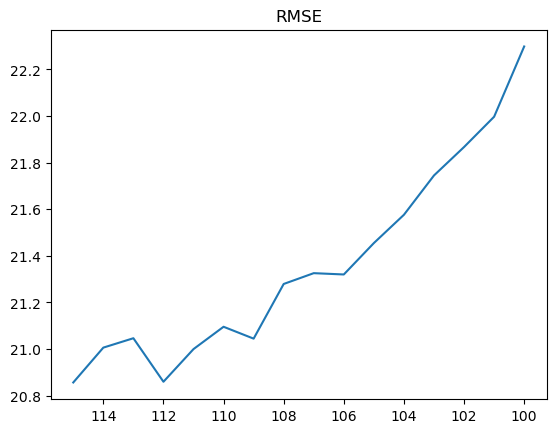

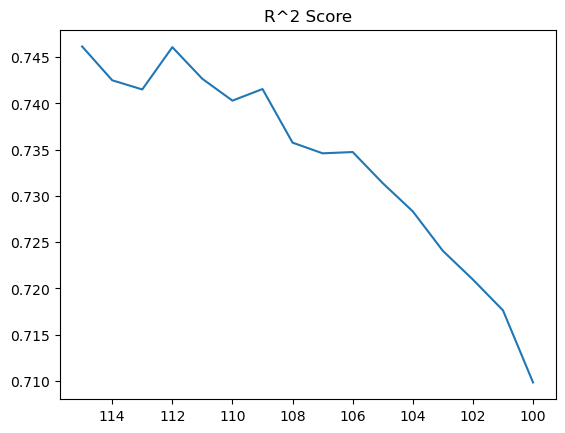

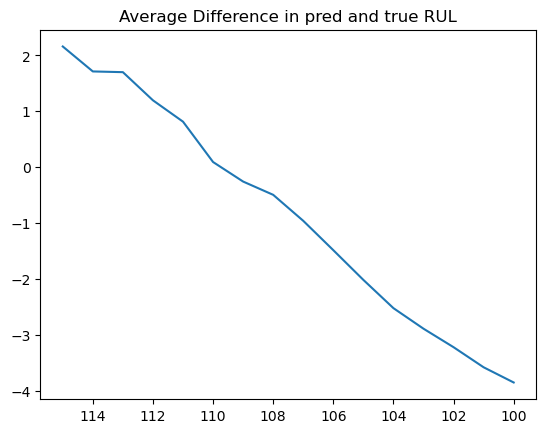

In [ ]:
# Testing for what clipping effect had on data
rmse_test_list = []
score_test_list = []
avg_test_list =[]
min_range = 100
max_range = 116
for i in range(min_range, max_range):
    y_train_clipped_df = y_train_df.clip(upper=i)
    rfr.fit(X_train_df, y_train_clipped_df)
    y_pred = rfr.predict(X_test_df)
    mse = mean_squared_error(y_test_df, y_pred)
    rmse_test_list.append(np.sqrt(mse))
    score_test_list.append(rfr.score(X_test_df, y_test_df))
    # Average prediction was high or low compared to actual
    avg_test_list.append(np.mean(y_pred - y_test_df))
plt.plot(range(min_range, max_range), rmse_test_list)
plt.title('RMSE')
plt.gca().invert_xaxis()
plt.show()
plt.plot(range(min_range, max_range), score_test_list)
plt.title('R^2 Score')
plt.gca().invert_xaxis()
plt.show()
plt.plot(range(min_range, max_range), avg_test_list)
plt.title('Average Difference in pred and true RUL')
plt.gca().invert_xaxis()
plt.show()

* Average score for Random Forest Regressor: 0.49154279252979227
* RMSE: 21.16981466617032
* Score: 0.738467740034183
* The Average Difference between pred and true: 5.5519

In [ ]:
# # attempt at finding better potential values
# param_grid = {
#     "regressor__n_estimators": [100, 150, 200],
#     "regressor__max_depth": [None, 5, 10]
# }

# grid_search = GridSearchCV(rfr, param_grid, cv=3, n_jobs=-1)
# grid_search.fit(X_train_df, y_train_df)

In [ ]:
# print("\n--- BEST PARAMETERS AFTER GRID SEARCH ---")
# print(grid_search.best_params_)

# best_model = grid_search.best_estimator_
# y_pred_best = best_model.predict(X_test_df)
# mse = mean_squared_error(y_test_df, y_pred_best)
# print("RMSE:", np.sqrt(mse))
# print("Score:", best_model.score(X_test_df, y_test_df))